<a href="https://colab.research.google.com/github/amritveersingh089-art/Python-Data-Processing-and-Visualisation-Notebook-/blob/main/Python_Data_Processing_and_Visualisation_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [4]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
complaints = pd.read_csv("complaints.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
app_events = pd.read_csv("app_events.csv")
incidents = pd.read_csv("incidents.csv")
hubs = pd.read_csv("hubs.csv")

print("Data loaded successfully")

Data loaded successfully


In [5]:
zone_cols = {
    "customers": "home_zone",
    "drivers": "base_zone",
    "orders_pickup": "pickup_zone",
    "orders_dropoff": "dropoff_zone",
    "vehicles": "assigned_zone"
}

customers["home_zone"] = customers["home_zone"].str.upper()
drivers["base_zone"] = drivers["base_zone"].str.upper()
orders["pickup_zone"] = orders["pickup_zone"].str.upper()
orders["dropoff_zone"] = orders["dropoff_zone"].str.upper()
vehicles["assigned_zone"] = vehicles["assigned_zone"].str.upper()

vehicles = vehicles.dropna(subset=["battery_health_pct"])
customers = customers.dropna(subset=["loyalty_score","app_engagement_score"])

print("Data cleaned")

Data cleaned


# Analysis 1: Revenue by service type

In [ ]:
revenue_service = orders.groupby("service_type")["order_value"].agg(["count","mean","sum"])
print(revenue_service)

              count       mean       sum
service_type                            
Business        165  92.245030  15220.43
Medical         139  87.136187  12111.93
Parcel          308  87.615649  26985.62
Passenger       341  96.073636  32761.11
Retail          297  90.013670  26734.06


## Visualization 1 — Revenue by service type

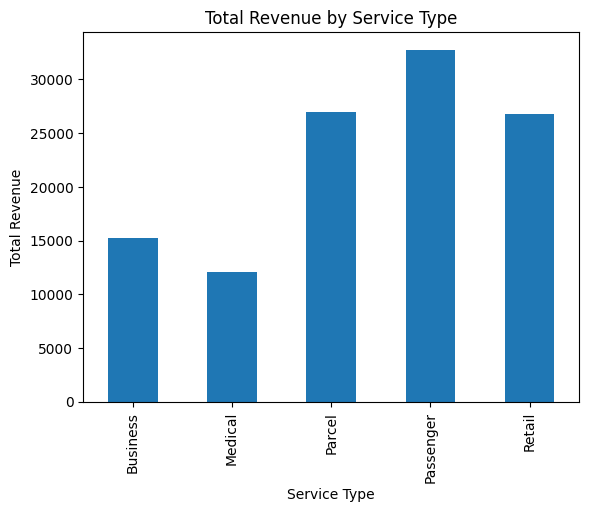

In [ ]:
revenue_service["sum"].plot(kind="bar")

plt.title("Total Revenue by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Revenue")

plt.show()

# Analysis 2: Complaint cost impact

In [ ]:
complaint_cost = complaints.groupby("complaint_type")["compensation_amount"].agg(["count","mean","sum"])
print(complaint_cost)

                   count       mean      sum
complaint_type                              
AppIssue              50  19.614400   980.72
Billing               16  23.871250   381.94
Damage                15  23.982000   359.73
Delay                 94  18.051489  1696.84
DriverBehaviour       46  21.153478   973.06
MissedPickup          63  22.593651  1423.40
SupportExperience     20  17.125000   342.50


## Visualization 2 — Compensation cost impact

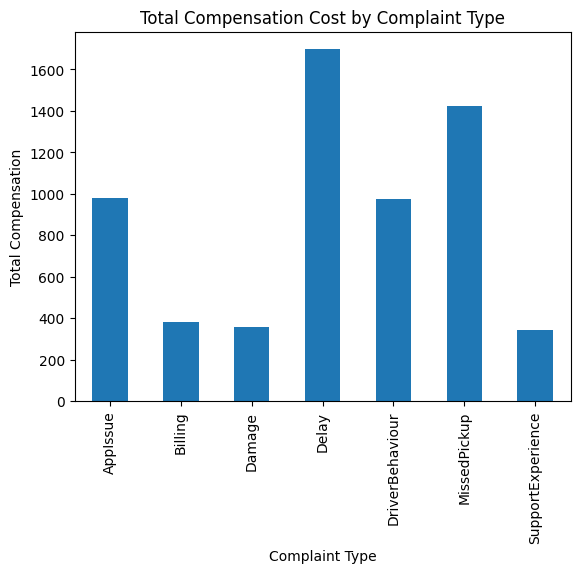

In [ ]:
complaint_cost["sum"].plot(kind="bar")

plt.title("Total Compensation Cost by Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Total Compensation")

plt.show()

# Analysis 3: Customer engagement vs loyalty

In [ ]:
correlation = customers["loyalty_score"].corr(customers["app_engagement_score"])
print("Correlation:", correlation)

Correlation: 0.03566775849639315


## Visualization 3 — Engagement vs loyalty relationship

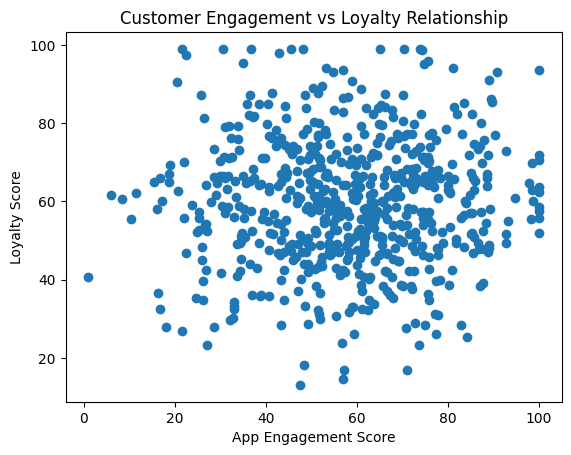

In [ ]:
plt.scatter(customers["app_engagement_score"],
            customers["loyalty_score"])

plt.title("Customer Engagement vs Loyalty Relationship")
plt.xlabel("App Engagement Score")
plt.ylabel("Loyalty Score")

plt.show()

# Analysis 4: Driver performance risk

In [ ]:
driver_stats = drivers.groupby("base_zone")["driver_rating"].agg(["mean","min","max"])
print(driver_stats)

               mean   min   max
base_zone                      
AIRPORT    4.212632  3.54  5.00
CENTRAL    4.198182  3.32  5.00
CTR        4.245000  3.71  4.61
EAST       4.115714  3.36  4.69
NORTH      4.086667  3.15  5.00
RIVERSIDE  4.235882  3.35  4.97
SOUTH      4.255517  3.55  5.00
WEST       4.117500  3.15  4.84


## Visualization 4 — Driver rating variation

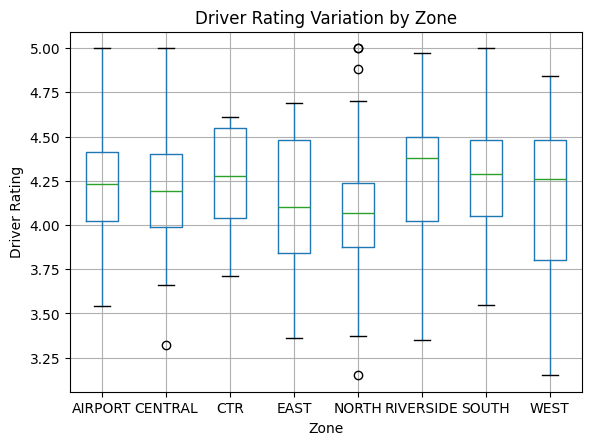

In [ ]:
drivers.boxplot(column="driver_rating", by="base_zone")

plt.title("Driver Rating Variation by Zone")
plt.suptitle("")
plt.xlabel("Zone")
plt.ylabel("Driver Rating")

plt.show()

# Analysis 5: Fleet risk indicators

In [ ]:
fleet_risk = vehicles.groupby("vehicle_type")["battery_health_pct"].agg(["mean","min","max"])
print(fleet_risk)

                   mean   min    max
vehicle_type                        
CargoVan      73.383333  47.6   93.6
Diesel        70.563158  42.0   90.4
EV            82.124390  63.5  100.0
Hybrid        76.838462  49.7  100.0


## Visualization 5 — Battery health risk

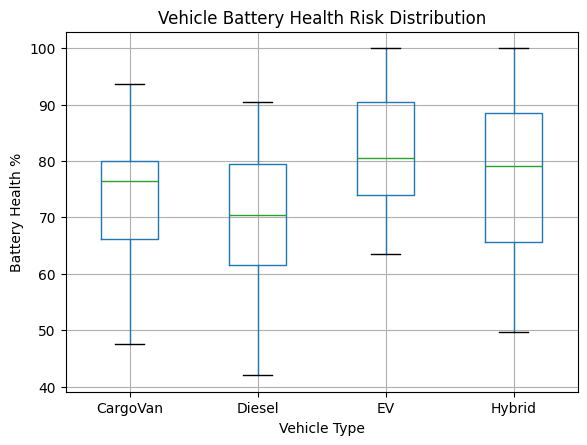

In [ ]:
vehicles.boxplot(column="battery_health_pct", by="vehicle_type")

plt.title("Vehicle Battery Health Risk Distribution")
plt.suptitle("")
plt.xlabel("Vehicle Type")
plt.ylabel("Battery Health %")

plt.show()

# Analysis 6: App performance efficiency

In [13]:
app_perf = app_events.groupby("device_type")["api_latency_ms"].agg(["mean","max","count"])
print(app_perf)

                   mean   max  count
device_type                         
Android      464.898413  1690    315
Web          474.684783  1633     92
iOS          463.145923  1701    233


## Visualization 6 — API latency performance

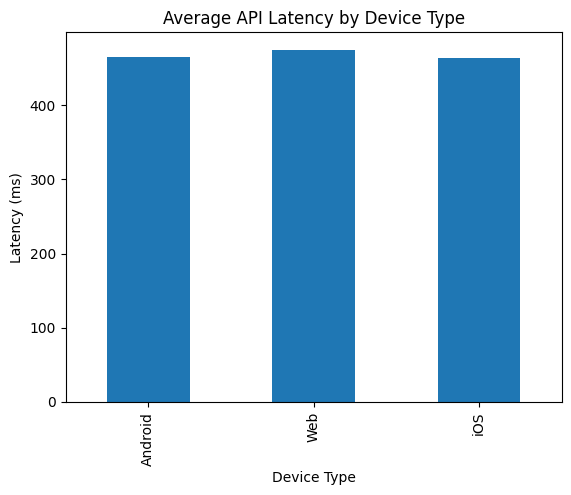

In [14]:
app_perf["mean"].plot(kind="bar")

plt.title("Average API Latency by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Latency (ms)")

plt.show()

# Analysis 7 — Order Value Distribution by Priority Level

Identifies whether high priority jobs generate higher revenue and require resource focus.

In [6]:
priority_analysis = orders.groupby("priority_level")["order_value"].agg(["mean","sum","count"])

priority_analysis

,mean,sum,count
priority_level,,,
Critical,89.384505,8133.99,91
High,95.663701,29464.42,308
Low,88.657672,30852.87,348
Medium,90.182644,45361.87,503


Visualization

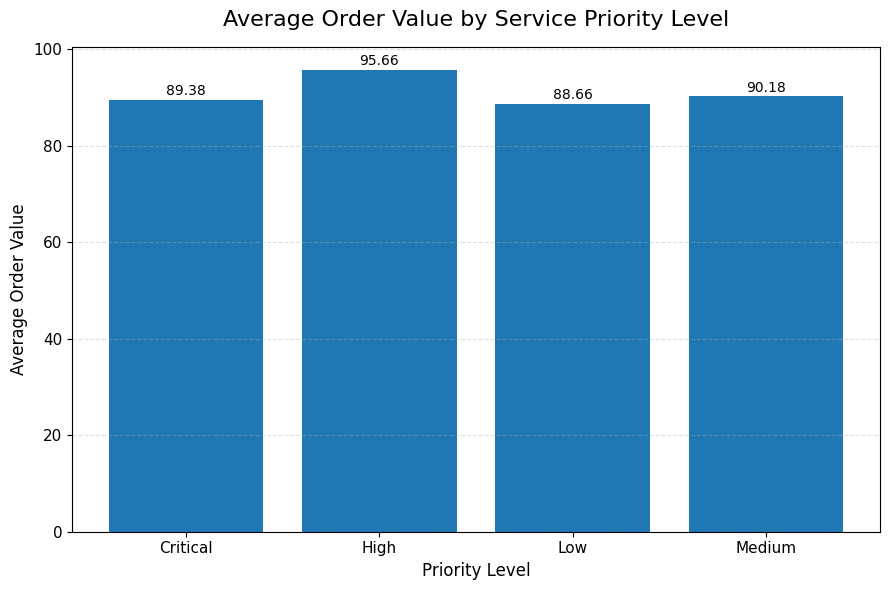

In [15]:
import numpy as np
import matplotlib.pyplot as plt

priority_analysis = orders.groupby("priority_level")["order_value"].agg(["mean","sum","count"]).reset_index()

x = np.arange(len(priority_analysis["priority_level"]))
y = priority_analysis["mean"]

plt.figure(figsize=(9,6))

bars = plt.bar(x, y)

plt.xticks(x, priority_analysis["priority_level"], fontsize=11)
plt.yticks(fontsize=11)

plt.title("Average Order Value by Service Priority Level",
          fontsize=16,
          pad=15)

plt.xlabel("Priority Level", fontsize=12)
plt.ylabel("Average Order Value", fontsize=12)

# add value labels on top
for i, v in enumerate(y):
    plt.text(i, v + 1, round(v,2),
             ha='center',
             fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Analysis 8 — Driver Experience vs Rating Relationship

Identifies whether more experienced drivers actually perform better.

In [8]:
experience_rating = drivers[["years_experience","driver_rating"]]

correlation_exp = experience_rating.corr()

print(correlation_exp)

                  years_experience  driver_rating
years_experience           1.00000        0.06284
driver_rating              0.06284        1.00000


## Visualization

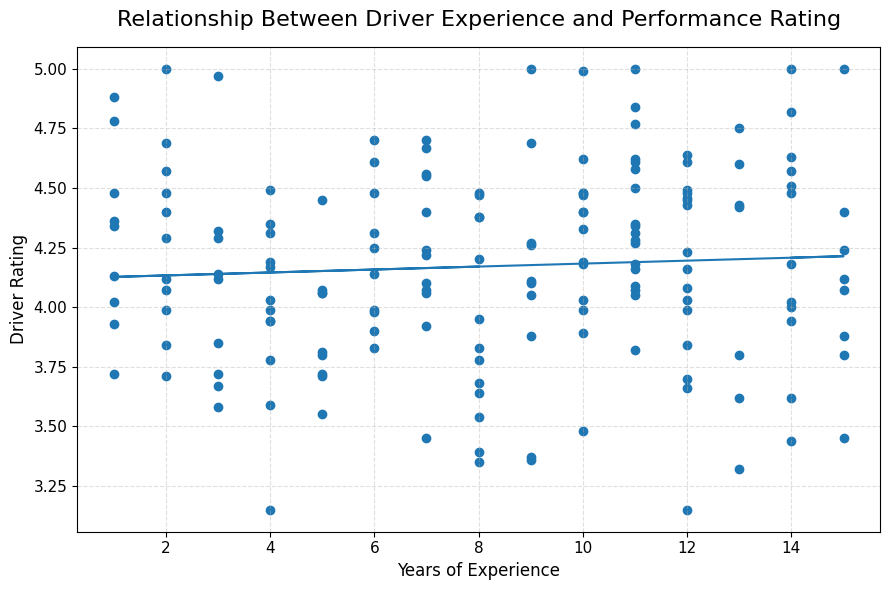

In [11]:
plt.figure(figsize=(9,6))

x = drivers["years_experience"]
y = drivers["driver_rating"]

plt.scatter(x, y)

# trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x))

plt.title("Relationship Between Driver Experience and Performance Rating",
          fontsize=16,
          pad=15)

plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Driver Rating", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Insight:
Tests whether experience leads to better service reliability.